Base action-follow probabilities without tilt would be 0.5.

Tilted follow probabilities:
 [[0.425 0.575]
 [0.425 0.575]
 [0.425 0.575]
 [0.425 0.575]
 [0.425 0.575]]

Tilted transition matrix:
 [[[0.425 0.575 0.    0.    0.   ]
  [0.425 0.575 0.    0.    0.   ]]

 [[0.425 0.    0.575 0.    0.   ]
  [0.425 0.    0.575 0.    0.   ]]

 [[0.    0.425 0.    0.575 0.   ]
  [0.    0.425 0.    0.575 0.   ]]

 [[0.    0.    0.425 0.    0.575]
  [0.    0.    0.425 0.    0.575]]

 [[0.    0.    0.    0.425 0.575]
  [0.    0.    0.    0.425 0.575]]]

Step: 0, state: 2, action: 0, next state: 1, reward: 0.0, terminated: False, truncated: False

Step: 1, state: 1, action: 1, next state: 0, reward: 1.0, terminated: False, truncated: False

...

Step: 5, state: 3, action: 1, next state: 4, reward: 10.0, terminated: False, truncated: False

Step: 6, state: 4, action: 1, next state: 3, reward: 0.0, terminated: False, truncated: False

Step: 7, state: 3, action: 1, next state: 4, reward: 10.0, terminated: False, truncated: False

Step: 8, state: 4, action: 1, next state: 3, reward: 0.0, terminated: False, truncated: False

Step: 9, state: 3, action: 1, next state: 4, reward: 10.0, terminated: False, truncated: True

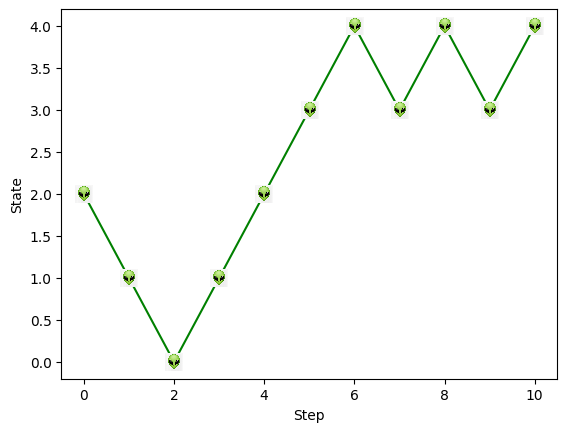

In [4]:
from __future__ import annotations

import matplotlib.pyplot as plt  # type: ignore[import]
import numpy as np
from matplotlib.offsetbox import AnnotationBbox, OffsetImage  # type: ignore[import]
from rich import print as printr
from rl_exercises.week_2.tilted_mars_rover import TiltedMarsRover

env = TiltedMarsRover(
    transition_probabilities=np.full((5, 2), 0.5),
    tilt_angle=15.0,
)
actions = [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1]

printr("Base action-follow probabilities without tilt would be 0.5.")
printr("Tilted follow probabilities:\n", env.P)
printr("Tilted transition matrix:\n", env.transition_matrix)

states = []
s, info = env.reset()
states.append(s)
for i in range(env.horizon):
    action = actions[i]
    s_next, r, terminated, truncated, info = env.step(action)
    printr(
        f"Step: {i}, state: {s}, action: {action}, next state: {s_next}, "
        f"reward: {r}, terminated: {terminated}, truncated: {truncated}"
    )
    s = s_next
    states.append(s)

# Plot
fig, ax = plt.subplots()
image = plt.imread("figures/alien_1f47d.png")
image_box = OffsetImage(image, zoom=0.01)
x = np.arange(0, len(states))
y = states
for x0, y0 in zip(x, y):
    ab = AnnotationBbox(image_box, (x0, y0), frameon=False)
    ax.add_artist(ab)
ax.plot(x, y, c="green")
ax.set_xlabel("Step")
ax.set_ylabel("State")
plt.show()